/tmp/ipykernel_3150/4111014482.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed



Sample Data BEFORE cleaning:
 Price        Date       Close        High         Low        Open    Volume  \
Ticker                   AAPL        AAPL        AAPL        AAPL      AAPL   
0      2025-12-01  282.835358  283.155066  275.881873  277.750120  46587700   
1      2025-12-02  285.922455  287.131315  282.365785  282.735435  53669500   
2      2025-12-03  283.884369  288.350192  283.035157  285.932471  43538700   
3      2025-12-04  280.437592  284.463823  278.329548  283.834407  43989100   
4      2025-12-05  278.519379  280.877188  277.790050  280.277743  47265800   
5      2025-12-08  277.630219  279.408553  275.891824  277.869984  38211800   
6      2025-12-09  276.920868  279.768210  276.661132  277.899963  32193300   
7      2025-12-10  278.519379  279.488473  276.181570  277.490343  33038300   
8      2025-12-11  277.770081  279.328620  273.554024  278.839088  33248000   
9      2025-12-12  278.019867  278.958991  276.561240  277.640217  39532900   
10     2025-12-15  27

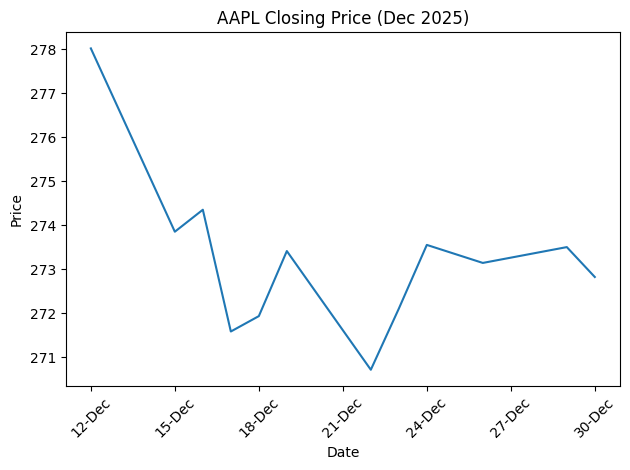

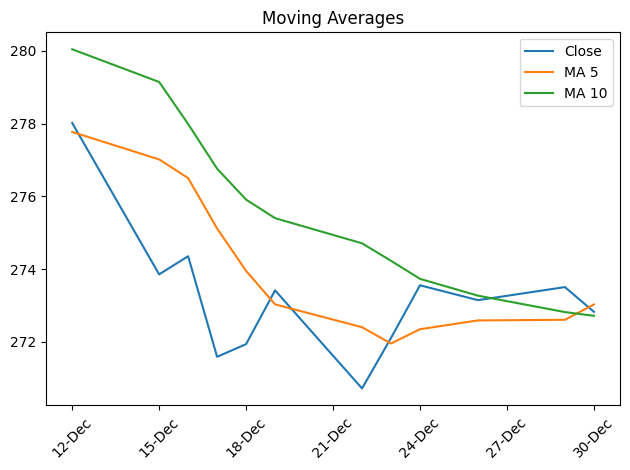

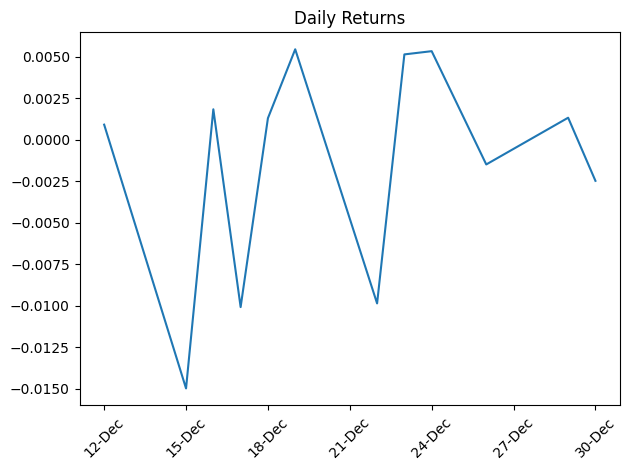

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# SETTINGS
stock_symbol = "AAPL"
start_date = "2025-12-01"
end_date = "2025-12-31"

# Install yfinance if needed
try:
    import yfinance as yf
except ImportError:
    os.system("pip install yfinance")
    import yfinance as yf

os.makedirs("plots", exist_ok=True)

# Download data
df = yf.download(stock_symbol, start=start_date, end=end_date)

if df.empty:
    print("No data found.")
    exit()


#  DATE

df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])


# CALCULATIONS

df['Returns'] = df['Close'].pct_change()
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()

print("\nSample Data BEFORE cleaning:\n", df.head(12))


# REMOVE NaN VALUES
df_clean = df.dropna().copy()

print("\nSample Data AFTER cleaning:\n", df_clean.head())


# DATE FORMATTER

def format_date_axis():
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.xticks(rotation=45)
    plt.tight_layout()


# 1. Closing Price

plt.figure()
plt.plot(df_clean['Date'], df_clean['Close'])
plt.title(f"{stock_symbol} Closing Price (Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Price")
format_date_axis()
plt.savefig("plots/closing_price.png")


# 2. Moving Averages

plt.figure()
plt.plot(df_clean['Date'], df_clean['Close'], label='Close')
plt.plot(df_clean['Date'], df_clean['MA_5'], label='MA 5')
plt.plot(df_clean['Date'], df_clean['MA_10'], label='MA 10')
plt.legend()
plt.title("Moving Averages")
format_date_axis()
plt.savefig("plots/moving_average.png")


# 3. Returns (FIXED)

plt.figure()
plt.plot(df_clean['Date'], df_clean['Returns'])
plt.title("Daily Returns")
format_date_axis()
plt.savefig("plots/returns.png")


# ANALYSIS

print("\n📊 Analysis Summary:")
print("Mean Return:", df_clean['Returns'].mean())
print("Volatility:", df_clean['Returns'].std())
print("Max Price:", df_clean['Close'].max())
print("Min Price:", df_clean['Close'].min())
